In [10]:
import numpy as np
import matplotlib.pyplot as plt
#
# Import the dd1D class and methods
#

import dd1D

Network relaxed using 241 steps


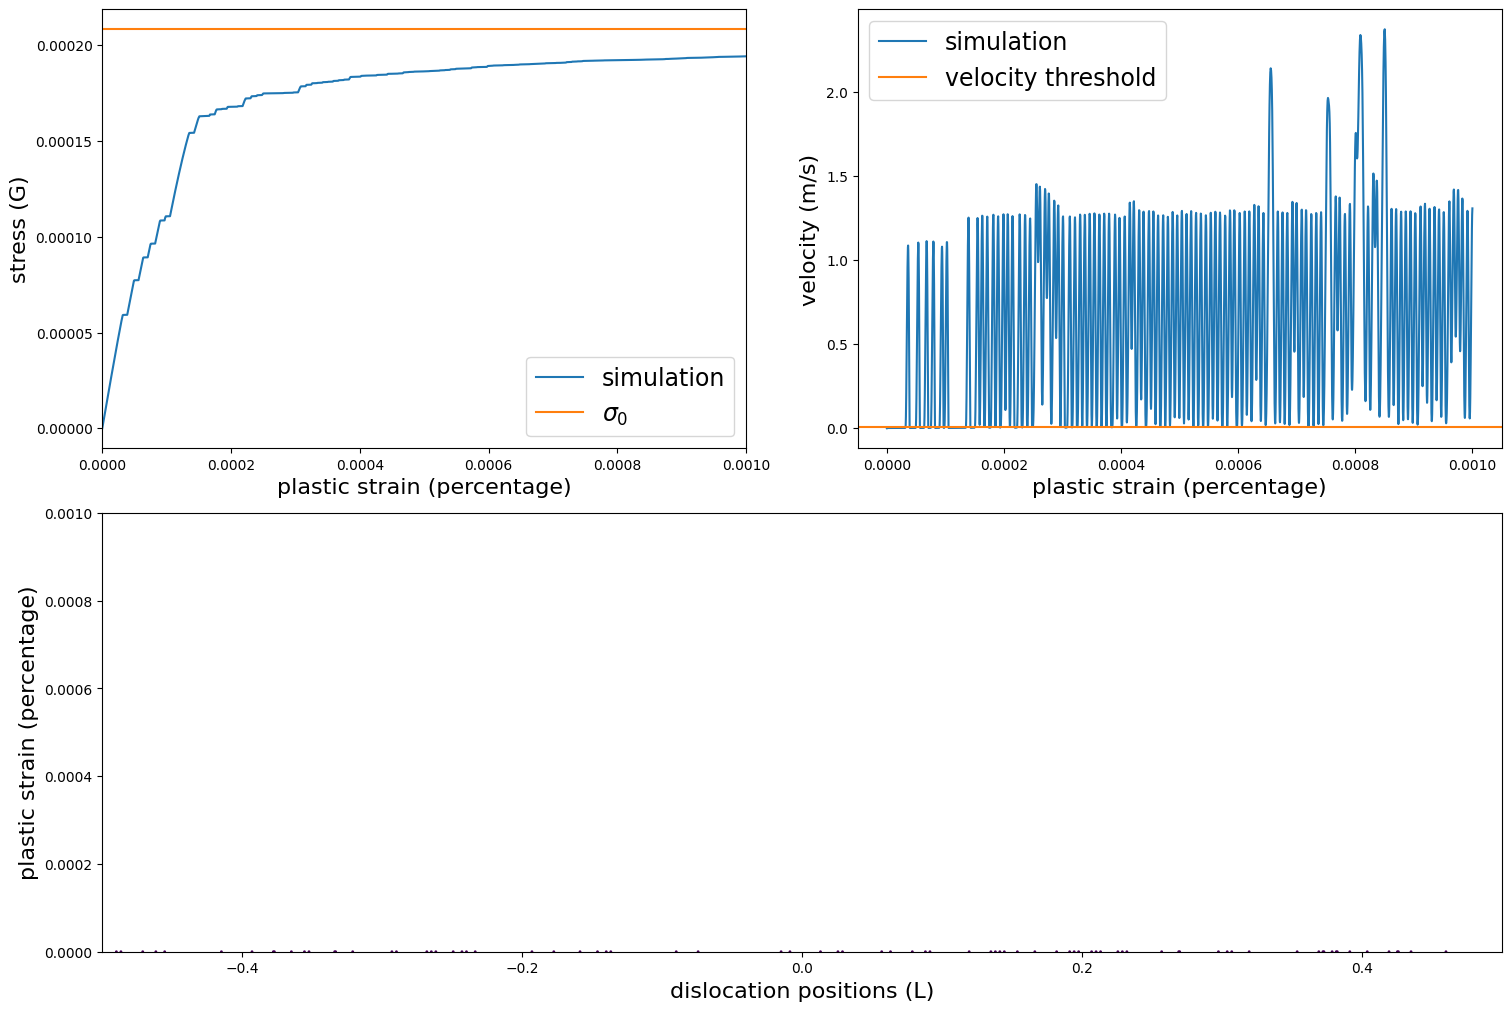

In [32]:
#
# Create an instance of the ddPSI class called mySystem containing twenty dislocations
#
mySystem=dd1D.dd1DClass(L = 4*160e-6,dislocationNumber=8*10)
#
# Relax the initial random configuration to a zero-force state for zero applied stress
#
totalPlasticStrain,stepNumber=mySystem.relaxNetwork(0.0)
#
#  Check if configuration satisfies relaxation threshold
#
if stepNumber==mySystem.stepNumberThreshold:
    print ('Network not relaxed')
    exit()
else:
    print ('Network relaxed using',stepNumber,'steps')
#
# Perform a constant stress rate deformation (stress rate defined by the product of strain rate and shear modulus)
#
strainRate=1.0
stressRate=mySystem.shearModulus*strainRate
deltaStress=stressRate*mySystem.timeStep
#
# Set maximum plastic strain by which to terminate simulation
#
maxPlasticStrain=1e-5 #1e-6
#
# Initialize deformation lists
#
appliedStressData=[]
plasticStrainData=[]
aveVelocityData=[]
#
# Initialize deformation variables
#
iterationNumber=0
appliedStress=0.0
plasticStrain=0.0
elasticStrain=0.0
aveDislocationVelocity=np.sum(mySystem.dislocationVelocity)/float(mySystem.dislocationNumber)
appliedStressData.append(appliedStress)
plasticStrainData.append(plasticStrain)
aveVelocityData.append(aveDislocationVelocity)
#
# Initialize sub plots
#
fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(2,2)
panel00 = fig.add_subplot(gs[0,0])
panel01 = fig.add_subplot(gs[0,1])
panel02 = fig.add_subplot(gs[1,:])
#
# Perform a constant stress rate deformation simulation
#
iterationNumber=0
#
# Output to subplot dislocation positions
#
panel02.scatter(mySystem.dislocationPosition/mySystem.L,y=np.array(mySystem.dislocationNumber*[100.0*plasticStrain]),\
                c=mySystem.dislocationVelocity,s=1,vmin=0, vmax=6)
while plasticStrain<maxPlasticStrain:
    iterationNumber+=1
    appliedStress+=deltaStress
    plasticStrainIncrement=mySystem.iterateNetwork(appliedStress)
    plasticStrain+=plasticStrainIncrement
    aveDislocationVelocity=np.sum(mySystem.dislocationVelocity)/float(mySystem.dislocationNumber)
    #
    # During inelastic regime store every 1000th data point, whilst during a plastic event store all data points
    # In the same way plot dislocation positions to subplot
    #
    if aveDislocationVelocity>0.01: #is something is hapeening save all data points
        appliedStressData.append(appliedStress)
        plasticStrainData.append(plasticStrain)
        aveVelocityData.append(aveDislocationVelocity)
        #panel02.scatter(mySystem.dislocationPosition/mySystem.L,y=np.array(mySystem.dislocationNumber*[100.0*plasticStrain]),\
        #        c=mySystem.dislocationVelocity,s=1,vmin=0, vmax=6)
    elif iterationNumber%1000==0: #if nothing is happening save every 1000th data point
        appliedStressData.append(appliedStress)
        plasticStrainData.append(plasticStrain)
        aveVelocityData.append(aveDislocationVelocity)
        #panel02.scatter(mySystem.dislocationPosition/mySystem.L,y=np.array(mySystem.dislocationNumber*[100.0*plasticStrain]),\
        #        c=mySystem.dislocationVelocity,s=1, vmin=0, vmax=6)
#
# Plot the stress versus plastic strain deformation curve 
#
panel00.set_xlabel(r'plastic strain (percentage)',fontsize=16)
panel00.set_ylabel(r'stress (G)',fontsize=16)
panel00.set_xlim([0.0,maxPlasticStrain*100.0])
panel00.plot([x*100.0 for x in plasticStrainData],[x/mySystem.shearModulus for x in appliedStressData],label=r'simulation',c='C0')
panel00.axhline(y=mySystem.sigma0/mySystem.shearModulus,label=r'$\sigma_{0}$',c='C1')
handles, labels = panel00.get_legend_handles_labels()
panel00.legend(handles, labels,fontsize=17,loc='lower right')
#
# Plot the average dislocation velocity versus plastic strain
#
panel01.set_xlabel(r'plastic strain (percentage)',fontsize=16)
panel01.set_ylabel(r'velocity (m/s)',fontsize=16)
panel01.plot([x*100.0 for x in plasticStrainData],aveVelocityData,label='simulation',c='C0')
panel01.axhline(y=0.01,label=r'velocity threshold',c='C1')
handles, labels = panel01.get_legend_handles_labels()
panel01.legend(handles, labels,fontsize=17,loc='upper left')
#
# Finish up dislocation position versus plastic strain plot
#
panel02.set_xlabel(r'dislocation positions (L)',fontsize=16)
panel02.set_ylabel(r'plastic strain (percentage)',fontsize=16)
panel02.set_xlim([-1.0/2.0,1.0/2.0])
panel02.set_ylim([0.0,100.0*plasticStrain])
#
# Set figure size and plot
#
fig.set_figheight(10)
fig.set_figwidth(15)
plt.show()
fig.savefig('deform1D.png')